In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO("yolo11n.pt")

In [ ]:
pred = model.predict("/content/air.png")[0]


image 1/1 /content/air.png: 448x640 1 airplane, 8.5ms
Speed: 2.8ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


In [19]:
from PIL import Image as PImage

array([[[185, 140, 103],
        [185, 140, 103],
        [185, 140, 103],
        ...,
        [184, 139, 102],
        [181, 136,  99],
        [181, 136,  99]],

       [[185, 140, 103],
        [185, 140, 103],
        [185, 140, 103],
        ...,
        [184, 139, 102],
        [183, 138, 101],
        [183, 138, 101]],

       [[185, 140, 103],
        [185, 140, 103],
        [185, 140, 103],
        ...,
        [184, 139, 102],
        [185, 140, 103],
        [185, 140, 103]],

       ...,

       [[173, 150, 128],
        [173, 150, 128],
        [173, 150, 128],
        ...,
        [169, 146, 124],
        [171, 148, 126],
        [171, 148, 126]],

       [[160, 137, 115],
        [160, 137, 115],
        [160, 137, 115],
        ...,
        [157, 134, 112],
        [159, 136, 114],
        [159, 136, 114]],

       [[210, 189, 167],
        [210, 189, 167],
        [210, 189, 167],
        ...,
        [207, 186, 164],
        [208, 187, 165],
        [208, 187, 165]]], dtype=uint8)
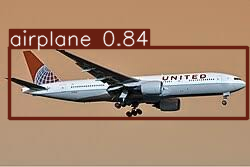

In [ ]:
pred.plot()


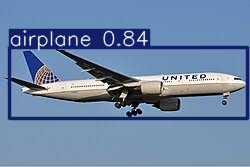

In [ ]:
pred.show()

In [4]:
import zipfile

In [5]:
zip = zipfile.ZipFile("/content/skin.yolov11.zip")

In [6]:
zip.extractall()

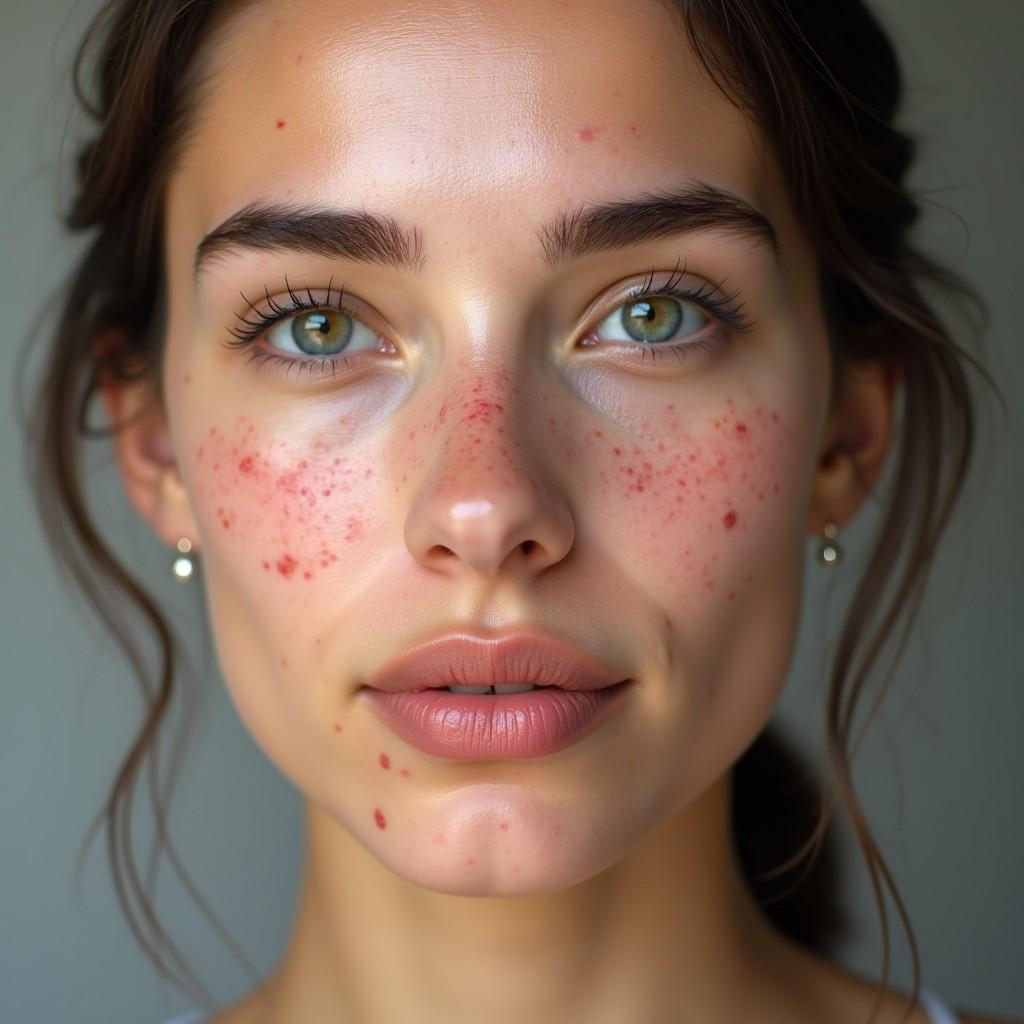

In [9]:
Image.open("/content/test/images/getimg_ai_img-hDRdk7zh7y3A446Z5zHCb_jpeg_jpg.rf.Tkd6cdq9yMHXyUurXqRu.jpg")

In [10]:
# Train with improved hyperparameters for better acne detection
results = model.train(
    data="/content/data.yaml",
    epochs=100,  # Increased epochs for better convergence
    imgsz=640,
    batch=8,  # Smaller batch size for better gradient updates
    lr0=0.01,  # Higher initial learning rate
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=5,  # Longer warmup
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,  # Add rotation
    translate=0.1,
    scale=0.5,
    shear=2.0,  # Add shear transformation
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0,
    patience=50,  # Early stopping patience
    save=True,
    device=0,  # Use GPU
    plots=True,
    val=True,
    close_mosaic=10,  # Disable mosaic in last 10 epochs
    optimizer='AdamW',  # Use AdamW optimizer
    cos_lr=True  # Use cosine learning rate scheduler
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optim

In [11]:
# Load the trained model for evaluation
new_model = YOLO("/content/runs/detect/train/weights/best.pt")

# Evaluate on validation set
metrics = new_model.val(split='val')
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2567.3±567.7 MB/s, size: 79.9 KB)
val: Scanning /content/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 5.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5it/s 1.4s
                   all         19        193      0.476      0.415      0.397      0.129
Speed: 13.8ms preprocess, 29.6ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.39731468509638435
mAP50-95: 0.12938313826276845
Precision: 0.47624494894177294
Recall: 0.4145988336289931


In [12]:
# Check class distribution in the dataset
import yaml
import os

with open('/content/data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset configuration:")
print(f"Train path: {data_config.get('train')}")
print(f"Val path: {data_config.get('val')}")
print(f"Classes: {data_config.get('names')}")

# Count images in each split
train_path = data_config.get('train')
val_path = data_config.get('val')

if os.path.exists(train_path):
    train_images = len([f for f in os.listdir(train_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
    print(f"\nNumber of training images: {train_images}")

if os.path.exists(val_path):
    val_images = len([f for f in os.listdir(val_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
    print(f"Number of validation images: {val_images}")

Dataset configuration:
Train path: /content/train/images
Val path: /content/valid/images
Classes: ['acne']

Number of training images: 60
Number of validation images: 17


In [ ]:
# Create data.yaml if it doesn't exist
import yaml
import os

data_yaml_content = """
path: /content/dataset  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val  # val images (relative to 'path')

# Classes
names:
  0: acne
  1: blackhead
  2: cyst
  3: whitehead
"""

yaml_path = '/content/data.yaml'
if not os.path.exists(yaml_path):
    with open(yaml_path, 'w') as f:
        f.write(data_yaml_content)
    print("Created data.yaml at /content/data.yaml")
else:
    print("data.yaml already exists")


image 1/1 /content/test/images/piclumen-1733318244543_jpg.rf.lQNzpXLBoo1UyZOJhS3s.jpg: 640x640 (no detections), 7.8ms
Speed: 2.7ms preprocess, 7.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


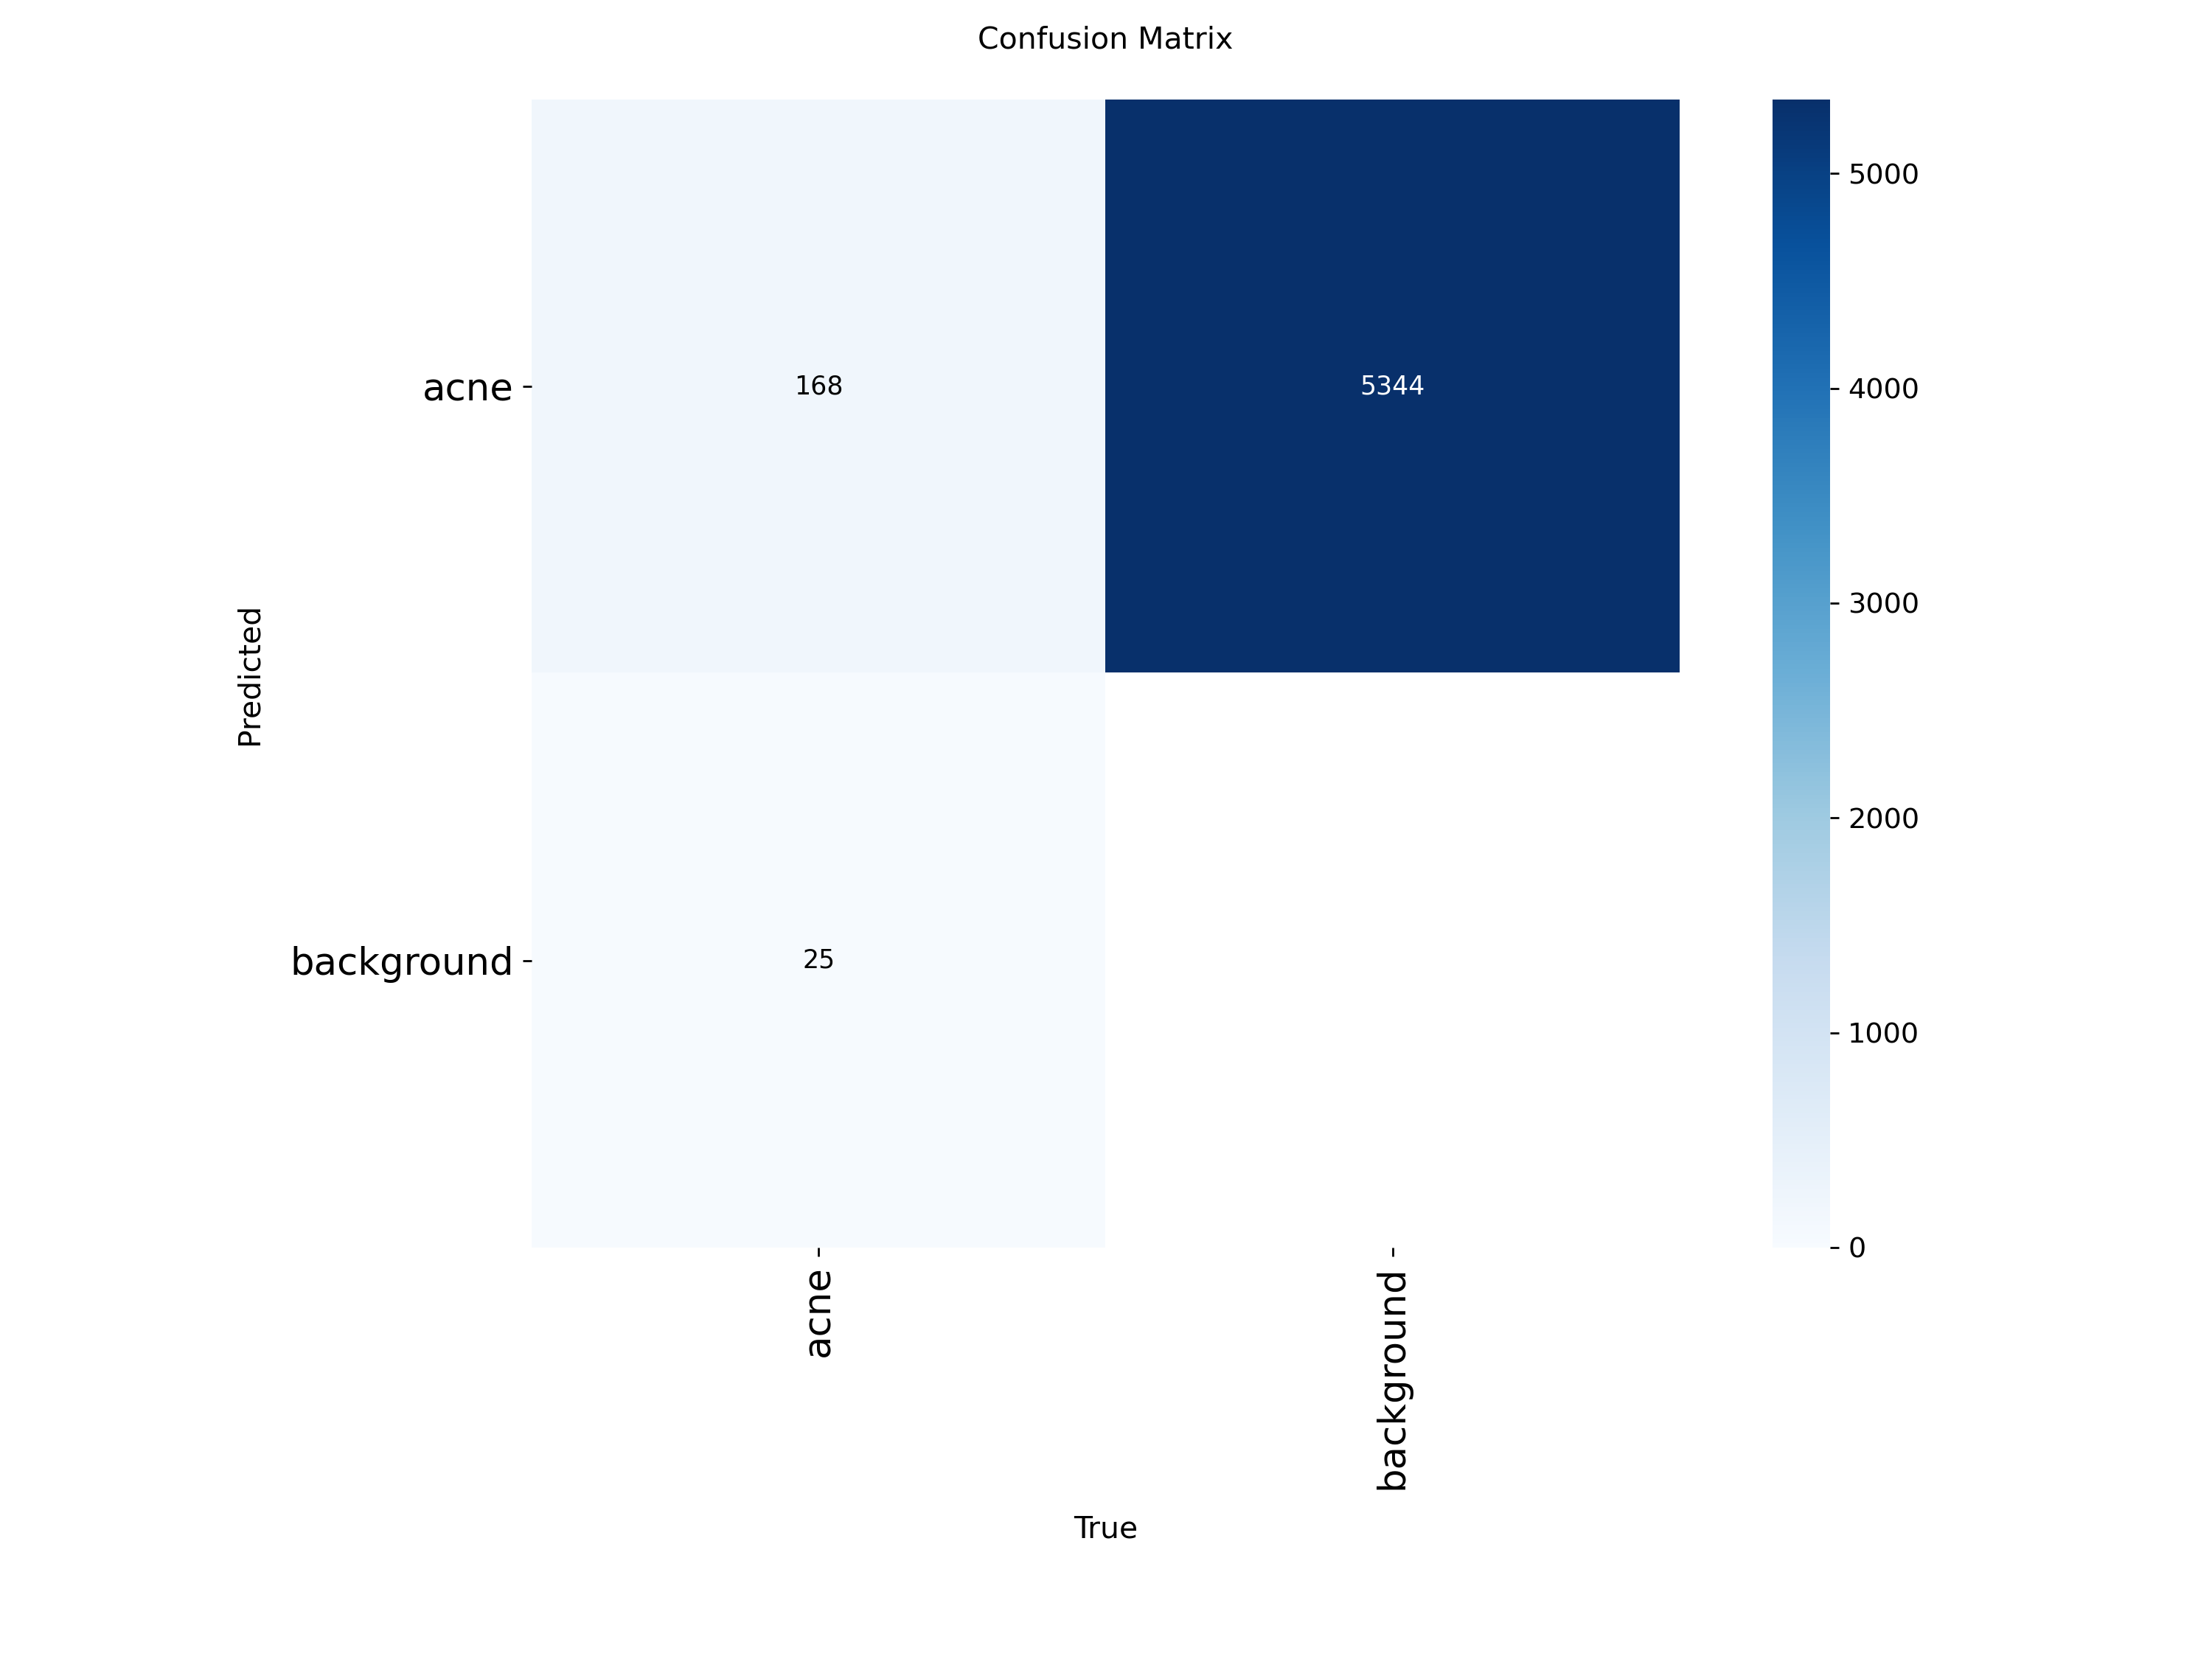

In [13]:
# Visualize training results
from IPython.display import Image, display

# Display confusion matrix
if os.path.exists('/content/runs/detect/train/confusion_matrix.png'):
    display(Image(filename='/content/runs/detect/train/confusion_matrix.png'))

# Display PR curve
if os.path.exists('/content/runs/detect/train/PR_curve.png'):
    display(Image(filename='/content/runs/detect/train/PR_curve.png'))

# Display F1 curve
if os.path.exists('/content/runs/detect/train/F1_curve.png'):
    display(Image(filename='/content/runs/detect/train/F1_curve.png'))

In [14]:
import gradio as gr

In [15]:
def gradio_interface(img):
  image = new_model.predict(img)
  image = image[0].plot()
  return image

In [16]:
app = gr.Interface(fn=gradio_interface,
             inputs=gr.Image("numpy"),
             outputs = gr.Image("numpy"))

In [17]:
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://84f1e6aa84d29d3869.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



image 1/1 /content/acne.jpg: 640x640 9 acnes, 10.8ms
Speed: 3.0ms preprocess, 10.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


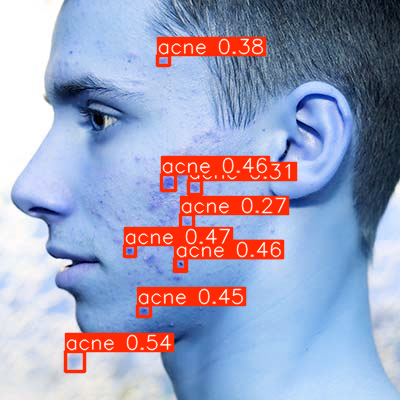

In [20]:
pred_acne = new_model.predict('/content/acne.jpg')[0]
display(PImage.fromarray(pred_acne.plot()))

In [21]:
new_model.save('skinacne.pt')


image 1/1 /content/train/images/773a1e6fdf156cdceeaa86e98d62946f_jpg.rf.N8JcRYn6GvWxb50IilGG.jpg: 512x640 3 acnes, 130.6ms
Speed: 7.2ms preprocess, 130.6ms inference, 2.6ms postprocess per image at shape (1, 3, 512, 640)


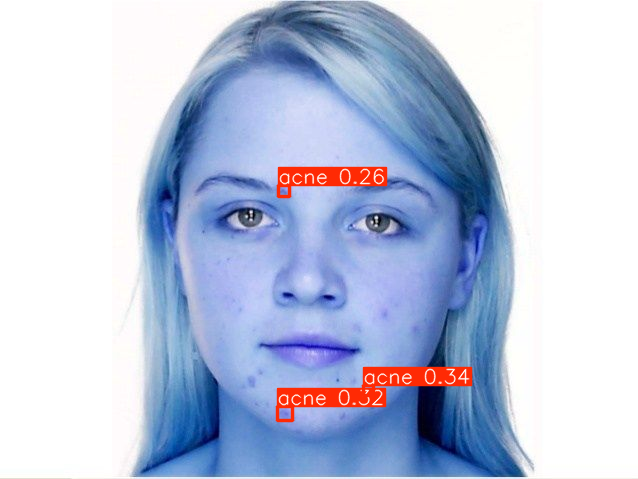

In [22]:
pred_acne = new_model.predict('/content/train/images/773a1e6fdf156cdceeaa86e98d62946f_jpg.rf.N8JcRYn6GvWxb50IilGG.jpg')[0]
display(PImage.fromarray(pred_acne.plot()))